In [2]:
import pandas as pd

# Load datasets
income_df = pd.read_excel('h08.xlsx', header=7)
hpi_df = pd.read_csv('hpi_master.csv')

print("Income file shape:", income_df.shape)
print("HPI file shape:", hpi_df.shape)

Income file shape: (108, 87)
HPI file shape: (133206, 10)


In [3]:
# Preview income data
print("=== INCOME DATA ===")
print(income_df.iloc[:, 0:3].head(15))

=== INCOME DATA ===
                   State           2024      Unnamed: 2
0                    NaN  Median income  Standard error
1          United States          83730             638
2                Alabama          65560            5862
3                 Alaska          91260            5591
4                Arizona          84700            3245
5               Arkansas          64840            1921
6             California         100600            1694
7               Colorado         106500            8547
8            Connecticut          99240            4631
9               Delaware          85860            3258
10  District of Columbia         104800            5094
11               Florida          75630            1788
12               Georgia          81210            2132
13                Hawaii          98240            4347
14                 Idaho          81650            2834


In [4]:
# Preview HPI data
print("=== HPI DATA ===")
hpi_state = hpi_df[hpi_df['level'] == 'State']
print(hpi_state[['place_name', 'yr', 'period', 'index_nsa']].head(15))
print()
print("Unique frequencies:", hpi_state['frequency'].unique())


=== HPI DATA ===
      place_name    yr  period  index_nsa
74443     Alaska  1975       1      62.03
74444     Alaska  1975       2      63.70
74445     Alaska  1975       3      66.62
74446     Alaska  1975       4      68.27
74447     Alaska  1976       1      70.76
74448     Alaska  1976       2      70.11
74449     Alaska  1976       3      74.67
74450     Alaska  1976       4      72.48
74451     Alaska  1977       1      78.09
74452     Alaska  1977       2      54.90
74453     Alaska  1977       3      79.98
74454     Alaska  1977       4      79.20
74455     Alaska  1978       1      78.78
74456     Alaska  1978       2      85.99
74457     Alaska  1978       3      87.15

Unique frequencies: <StringArray>
['quarterly']
Length: 1, dtype: str


In [5]:
# Filter HPI data for state level, all-transactions, 2019 and 2024
hpi_state = hpi_df[
    (hpi_df['level'] == 'State') &
    (hpi_df['hpi_flavor'] == 'all-transactions') &
    (hpi_df['yr'].isin([2019, 2024]))
]

# Average the 4 quarters to get one value per state per year
hpi_annual = hpi_state.groupby(['place_name', 'yr'])['index_nsa'].mean().reset_index()
print(hpi_annual.head(20))
print("Shape:", hpi_annual.shape)

              place_name    yr   index_nsa
0                Alabama  2019   262.38125
1                Alabama  2024   409.48375
2                 Alaska  2019   275.36875
3                 Alaska  2024   388.60625
4                Arizona  2019   328.37250
5                Arizona  2024   558.50125
6               Arkansas  2019   236.66750
7               Arkansas  2024   366.40000
8             California  2019   454.59500
9             California  2024   647.20500
10              Colorado  2019   426.96375
11              Colorado  2024   647.61375
12           Connecticut  2019   295.24000
13           Connecticut  2024   477.74250
14              Delaware  2019   468.14000
15              Delaware  2024   722.15500
16  District of Columbia  2019   892.63750
17  District of Columbia  2024  1048.03750
18               Florida  2019   380.38875
19               Florida  2024   652.43375
Shape: (102, 3)


In [6]:
# Create a pivot so each state has 2019 and 2024 as separate columns
hpi_pivot = hpi_annual.pivot(index='place_name', columns='yr', values='index_nsa').reset_index()
hpi_pivot.columns = ['state', 'hpi_2019', 'hpi_2024']

# Calculate price growth rate 2019-2024
hpi_pivot['price_growth'] = ((hpi_pivot['hpi_2024'] - hpi_pivot['hpi_2019']) / hpi_pivot['hpi_2019']) * 100

print(hpi_pivot.head(10))


                  state   hpi_2019    hpi_2024  price_growth
0               Alabama  262.38125   409.48375     56.064410
1                Alaska  275.36875   388.60625     41.122132
2               Arizona  328.37250   558.50125     70.081615
3              Arkansas  236.66750   366.40000     54.816356
4            California  454.59500   647.20500     42.369582
5              Colorado  426.96375   647.61375     51.678860
6           Connecticut  295.24000   477.74250     61.814964
7              Delaware  468.14000   722.15500     54.260478
8  District of Columbia  892.63750  1048.03750     17.409083
9               Florida  380.38875   652.43375     71.517625


In [7]:
# Clean income data using integer 2024 column
income_clean = income_df[['State', 2024]].copy()
income_clean.columns = ['state', 'median_income']

# Drop rows that are not actual states
income_clean = income_clean.dropna(subset=['state'])
income_clean = income_clean[income_clean['state'] != 'United States']
income_clean = income_clean[~income_clean['median_income'].astype(str).str.contains('Median|error|N', na=True)]

# Reset index
income_clean = income_clean.reset_index(drop=True)
print(income_clean.head(10))
print("Shape:", income_clean.shape)

                  state median_income
0               Alabama         65560
1                Alaska         91260
2               Arizona         84700
3              Arkansas         64840
4            California        100600
5              Colorado        106500
6           Connecticut         99240
7              Delaware         85860
8  District of Columbia        104800
9               Florida         75630
Shape: (103, 2)


In [8]:
# Merge income and HPI data on the state names
merged_df = pd.merge(income_clean, hpi_pivot, on='state', how='inner')

# Drop any duplicates
merged_df = merged_df.drop_duplicates(subset='state')

# Calculate affordability ratio (higher = more affordable)
merged_df['affordability_ratio'] = merged_df['median_income'] / merged_df['hpi_2024']

print(merged_df.head(10))
print("Shape:", merged_df.shape)

                  state median_income   hpi_2019    hpi_2024  price_growth  \
0               Alabama         65560  262.38125   409.48375     56.064410   
1                Alaska         91260  275.36875   388.60625     41.122132   
2               Arizona         84700  328.37250   558.50125     70.081615   
3              Arkansas         64840  236.66750   366.40000     54.816356   
4            California        100600  454.59500   647.20500     42.369582   
5              Colorado        106500  426.96375   647.61375     51.678860   
6           Connecticut         99240  295.24000   477.74250     61.814964   
7              Delaware         85860  468.14000   722.15500     54.260478   
8  District of Columbia        104800  892.63750  1048.03750     17.409083   
9               Florida         75630  380.38875   652.43375     71.517625   

  affordability_ratio  
0          160.104033  
1          234.839249  
2          151.655883  
3          176.965066  
4          155.437613

In [9]:
print("States in dataset:", merged_df.shape[0])
print()
print("Any missing values?")
print(merged_df.isnull().sum())

States in dataset: 51

Any missing values?
state                  0
median_income          0
hpi_2019               0
hpi_2024               0
price_growth           0
affordability_ratio    0
dtype: int64


In [10]:
# Keep only 50 states + DC
exclude = ['Puerto Rico', 'Guam', 'Virgin Islands', 'American Samoa', 'Northern Mariana Islands']
merged_df = merged_df[~merged_df['state'].isin(exclude)]

# Convert median_income to numeric just in case
merged_df['median_income'] = pd.to_numeric(merged_df['median_income'], errors='coerce')

print("Final dataset size:", merged_df.shape)
print()
print(merged_df['state'].unique())

Final dataset size: (51, 6)

<StringArray>
[             'Alabama',               'Alaska',              'Arizona',
             'Arkansas',           'California',             'Colorado',
          'Connecticut',             'Delaware', 'District of Columbia',
              'Florida',              'Georgia',               'Hawaii',
                'Idaho',             'Illinois',              'Indiana',
                 'Iowa',               'Kansas',             'Kentucky',
            'Louisiana',                'Maine',             'Maryland',
        'Massachusetts',             'Michigan',            'Minnesota',
          'Mississippi',             'Missouri',              'Montana',
             'Nebraska',               'Nevada',        'New Hampshire',
           'New Jersey',           'New Mexico',             'New York',
       'North Carolina',         'North Dakota',                 'Ohio',
             'Oklahoma',               'Oregon',         'Pennsylvania',
        

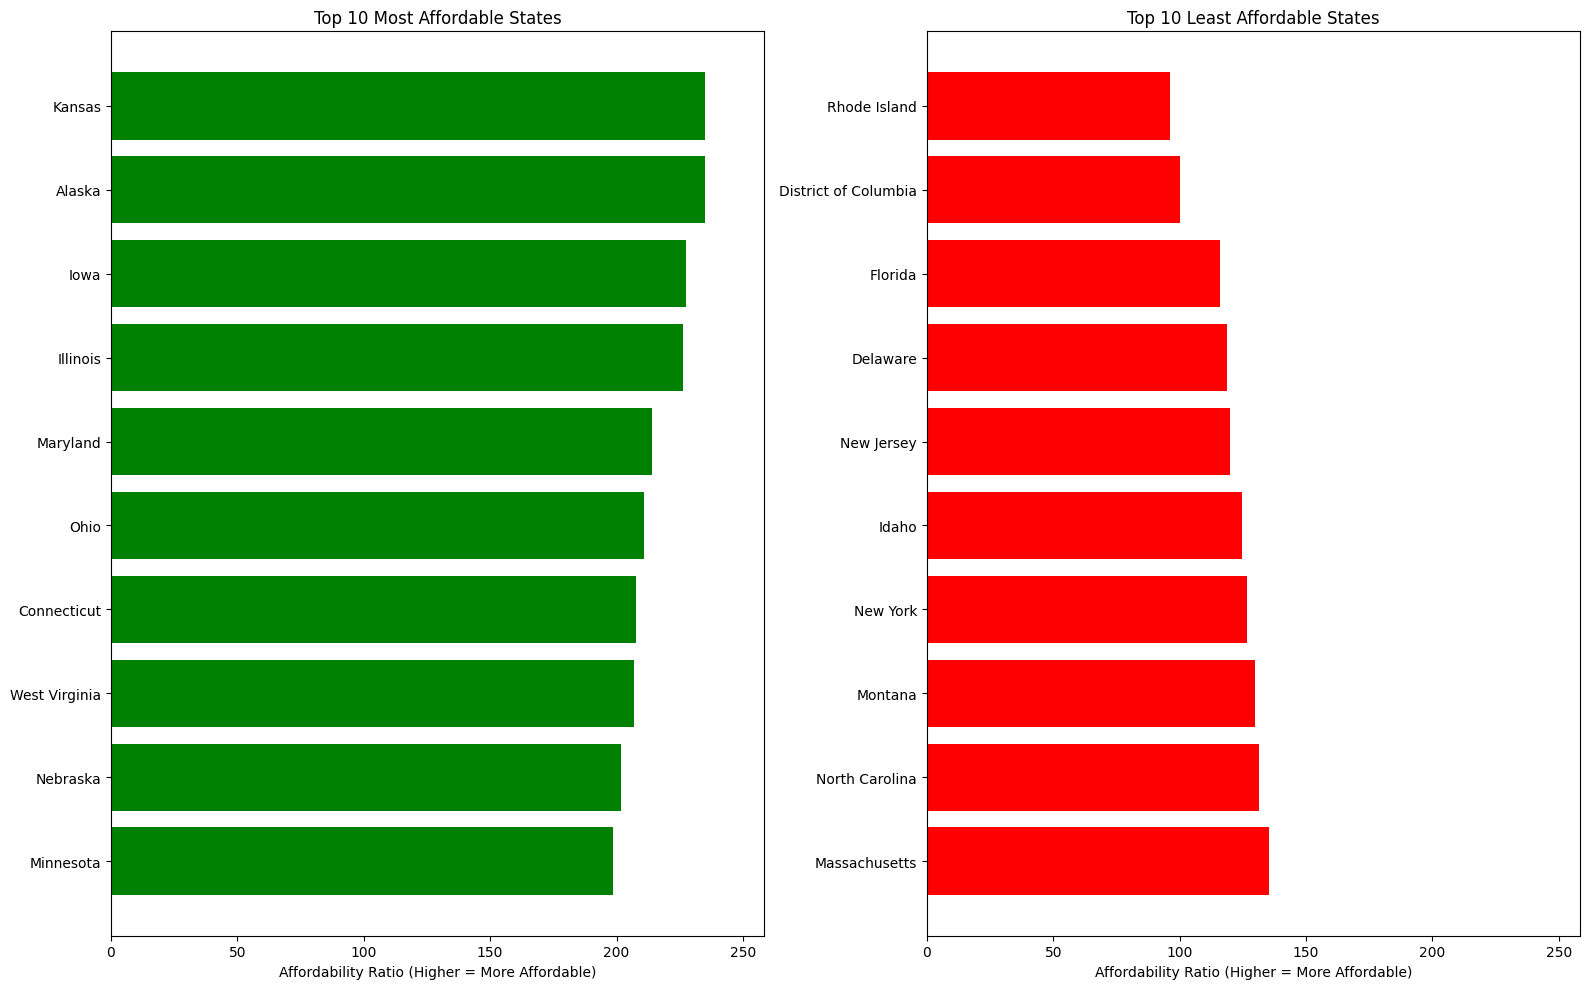

In [11]:
import matplotlib.pyplot as plt

# Sort by affordability ratio
sorted_df = merged_df.sort_values('affordability_ratio', ascending=True)

# Top 10 most affordable and least affordable
most_affordable = sorted_df.tail(10).sort_values('affordability_ratio', ascending=True)
least_affordable = sorted_df.head(10).sort_values('affordability_ratio', ascending=False)

# Get shared x axis max
x_max = most_affordable['affordability_ratio'].max() * 1.1

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# Most affordable is green and bigger bars
axes[0].barh(most_affordable['state'], most_affordable['affordability_ratio'], color='green')
axes[0].set_title('Top 10 Most Affordable States')
axes[0].set_xlabel('Affordability Ratio (Higher = More Affordable)')
axes[0].set_xlim(0, x_max)

# The least affordable is red and smaller bars 
axes[1].barh(least_affordable['state'], least_affordable['affordability_ratio'], color='red')
axes[1].set_title('Top 10 Least Affordable States')
axes[1].set_xlabel('Affordability Ratio (Higher = More Affordable)')
axes[1].set_xlim(0, x_max)

plt.tight_layout()
plt.savefig("most_vs_least_affordable.png", dpi=300, bbox_inches="tight")
plt.show()

In [12]:
print("Most affordable:")
print(most_affordable[['state', 'affordability_ratio']])
print()
print("Least affordable:")
print(least_affordable[['state', 'affordability_ratio']])

Most affordable:
            state affordability_ratio
23      Minnesota          198.637927
27       Nebraska          201.884316
48  West Virginia          206.778842
6     Connecticut          207.726966
35           Ohio          210.723282
20       Maryland          214.047214
13       Illinois          226.370968
15           Iowa          227.308687
1          Alaska          234.839249
16         Kansas          234.871084

Least affordable:
                   state affordability_ratio
21         Massachusetts          135.254285
33        North Carolina          131.315031
26               Montana          129.933007
32              New York          126.833187
12                 Idaho           124.67005
30            New Jersey          120.006609
7               Delaware          118.894143
9                Florida          115.919816
8   District of Columbia           99.996422
39          Rhode Island           96.379377


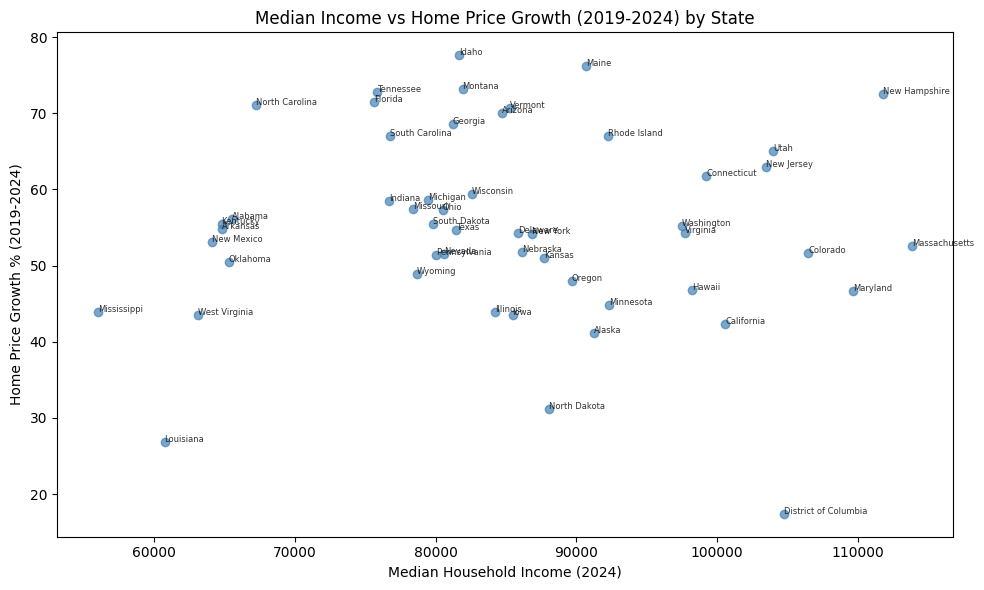

In [13]:
# Scatter plot with income vs price growth
plt.figure(figsize=(10, 6))
plt.scatter(merged_df['median_income'], merged_df['price_growth'], color='steelblue', alpha=0.7)

# Label each dot with each state name
for i, row in merged_df.iterrows():
    plt.annotate(row['state'], (row['median_income'], row['price_growth']), 
                fontsize=6, alpha=0.8)

plt.title('Median Income vs Home Price Growth (2019-2024) by State')
plt.xlabel('Median Household Income (2024)')
plt.ylabel('Home Price Growth % (2019-2024)')
plt.tight_layout()
plt.savefig("income_vs_price_growth.png", dpi=300, bbox_inches="tight")
plt.show()


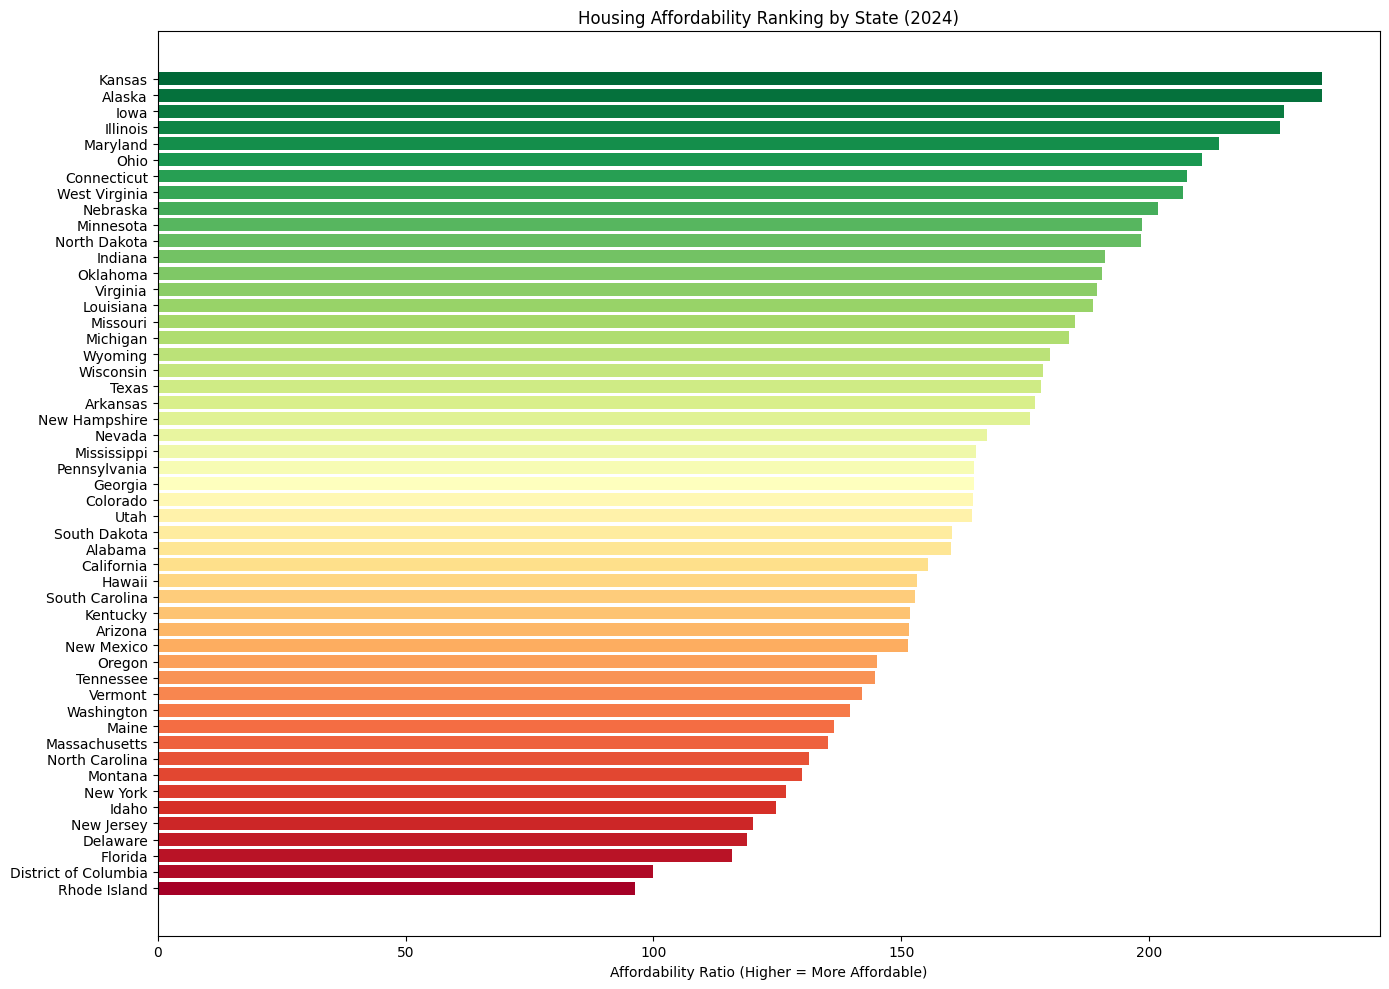

In [14]:
# income divided by hpi
merged_df['affordability_ratio'] = merged_df['median_income'] / merged_df['hpi_2024']

# sort low to high so the most affordable ends up on top
map_df = merged_df.sort_values('affordability_ratio', ascending=True).reset_index(drop=True)

# color gradient from red to yellow to green
import numpy as np
colors = plt.cm.RdYlGn(np.linspace(0, 1, len(map_df)))

plt.figure(figsize=(14, 10))
plt.barh(map_df['state'], map_df['affordability_ratio'], color=colors)
plt.xlabel('Affordability Ratio (Higher = More Affordable)')
plt.title('Housing Affordability Ranking by State (2024)')
plt.tight_layout()
plt.savefig("affordability_ranking.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# grab the columns needed
features = merged_df[['affordability_ratio', 'price_growth', 'median_income']]

# scale so kmeans works properly
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# run kmeans with 3 groups
kmeans = KMeans(n_clusters=3, random_state=42)
merged_df['cluster'] = kmeans.fit_predict(scaled_features)

print(merged_df[['state', 'affordability_ratio', 'price_growth', 'cluster']].sort_values('cluster'))

                   state  affordability_ratio  price_growth  cluster
2                Arizona           151.655883     70.081615        0
7               Delaware           118.894143     54.260478        0
10               Georgia           164.596793     68.596630        0
9                Florida           115.919816     71.517625        0
12                 Idaho           124.670050     77.615624        0
29         New Hampshire           176.093497     72.503948        0
30            New Jersey           120.006609     62.888238        0
19                 Maine           136.372518     76.168725        0
26               Montana           129.933007     73.225104        0
42             Tennessee           144.815211     72.728434        0
45               Vermont           142.105625     70.665979        0
44                  Utah           164.339187     64.979731        0
40        South Carolina           152.805903     66.989589        0
39          Rhode Island          

In [15]:
# check what each cluster looks like on average
print(merged_df.groupby('cluster')[['affordability_ratio', 'price_growth', 'median_income']].mean())

         affordability_ratio  price_growth  median_income
cluster                                                  
0                 137.295990     68.405238   86577.500000
1                 187.674045     50.810731   75547.826087
2                 166.794924     46.066972   99860.833333


In [16]:
# label the clusters based on what the averages showed
labels = {0: 'Low Affordability', 1: 'High Affordability', 2: 'Mid Affordability'}
merged_df['affordability_tier'] = merged_df['cluster'].map(labels)

# quick look at how states are grouped
print(merged_df[['state', 'affordability_tier']].sort_values('affordability_tier'))

                   state  affordability_tier
0                Alabama  High Affordability
48         West Virginia  High Affordability
43                 Texas  High Affordability
41          South Dakota  High Affordability
38          Pennsylvania  High Affordability
36              Oklahoma  High Affordability
35                  Ohio  High Affordability
31            New Mexico  High Affordability
28                Nevada  High Affordability
27              Nebraska  High Affordability
49             Wisconsin  High Affordability
24           Mississippi  High Affordability
22              Michigan  High Affordability
18             Louisiana  High Affordability
17              Kentucky  High Affordability
16                Kansas  High Affordability
25              Missouri  High Affordability
14               Indiana  High Affordability
1                 Alaska  High Affordability
3               Arkansas  High Affordability
15                  Iowa  High Affordability
50        

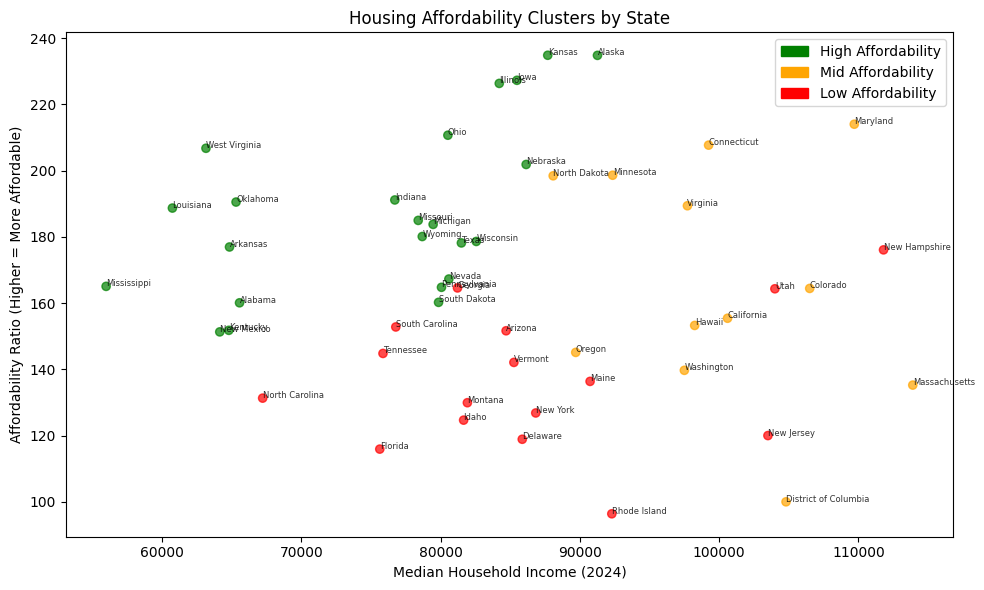

In [17]:
# plot the clusters on a scatter plot
colors_map = {'High Affordability': 'green', 'Mid Affordability': 'orange', 'Low Affordability': 'red'}
colors_list = merged_df['affordability_tier'].map(colors_map)

plt.figure(figsize=(10, 6))
plt.scatter(merged_df['median_income'], merged_df['affordability_ratio'], c=colors_list, alpha=0.7)

# label each dot
for i, row in merged_df.iterrows():
    plt.annotate(row['state'], (row['median_income'], row['affordability_ratio']), fontsize=6, alpha=0.8)

plt.xlabel('Median Household Income (2024)')
plt.ylabel('Affordability Ratio (Higher = More Affordable)')
plt.title('Housing Affordability Clusters by State')

# manual legend
import matplotlib.patches as mpatches
patches = [mpatches.Patch(color=v, label=k) for k, v in colors_map.items()]
plt.legend(handles=patches)

plt.tight_layout()
plt.show()

In [18]:
from sklearn.linear_model import LinearRegression
import numpy as np

# set up x and y
x = merged_df[['median_income', 'price_growth']]
y = merged_df['affordability_ratio']

# fit the model
model = LinearRegression()
model.fit(x, y)

# results
print("R-squared:", round(model.score(x, y), 3))
print("Coefficients:")
print("  median_income:", round(model.coef_[0], 4))
print("  price_growth:", round(model.coef_[1], 4))
print("  intercept:", round(model.intercept_, 3))

R-squared: 0.138
Coefficients:
  median_income: -0.0002
  price_growth: -0.9993
  intercept: 239.378


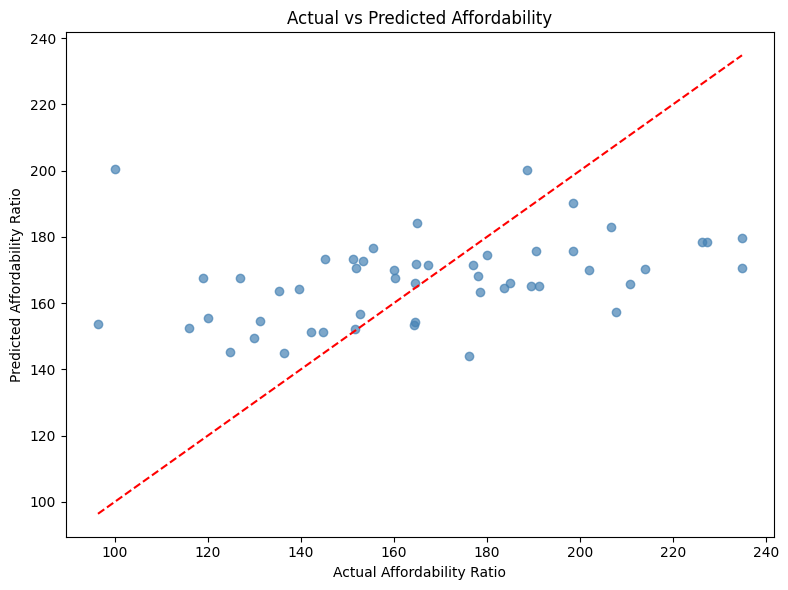

In [19]:
# plot actual vs predicted affordability
y_pred = model.predict(x)

plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, alpha=0.7, color='steelblue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel('Actual Affordability Ratio')
plt.ylabel('Predicted Affordability Ratio')
plt.title('Actual vs Predicted Affordability')
plt.tight_layout()
plt.show()